# Параметры моделирования и генерация сигнала

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def generate_signal(fs, T, f0):
  """Генерирует простой прямоугольный сигнал с заданными параметрами"""
  N = int(round(T * fs))
  t = np.arange(N) / fs
  signal = np.sin(2 * np.pi * f0 * t)
  return signal, t

def generate_lfm_pulse(fs, T, f_start, f_stop):
  """Генерирует прямоугольный радиоимпульс с внутриимпульсной ЛЧМ"""
  N = int(round(T * fs))
  t = np.arange(N) / fs
  k = (f_stop - f_start) / T
  signal = np.cos(2 * np.pi * (f_start * t + 0.5 * k * t**2))
  return signal, t

def generate_symmetric_lfm(fs, T, f_start, f_stop):
  """Генерирует прямоугольный радиоимпульс с внутриимпульсной симметричной ЛЧМ"""
  half_T = T / 2
  half_signal, half_t = generate_lfm_pulse(fs, half_T, f_start, f_stop) # Создаем ЛЧМ-импульс для половины времени
  reflected_signal = half_signal[::-1] # Создаем отраженный сигнал - вторую половину
  reflected_t = -half_t[::-1]
  full_signal = np.concatenate((reflected_signal, half_signal)) # Объединяем временные и сигнальные данные
  full_t = np.concatenate((reflected_t, half_t))
  full_t += abs(full_t[0]) # Сдвигаем временную шкалу на положительную полуплоскость
  return full_signal, full_t

def generate_bpsk(fs, T, f0):
  """Генерирует BPSK-сигнал со случайной битовой последовательностью"""
  N = int(round(T * fs))
  t = np.arange(N) / fs
  bit_count = 10
  bit_duration = T / bit_count
  bits = np.random.randint(0, 2, bit_count)
  signal = np.zeros_like(t)
  for i, bit in enumerate(bits):
    phase = 0 if bit == 0 else np.pi
    t_bit = (t >= i * bit_duration) & (t < (i + 1) * bit_duration)
    signal[t_bit] = np.cos(2 * np.pi * f0 * t[t_bit] + phase)
  return signal, t

def generate_ofdm(fs, T, f0):
  """Генерирует OFDM-сигнал со случайными фазами"""
  N = int(round(T * fs))
  t = np.arange(N) / fs
  freqs = np.arange(0.1*f0, f0, 0.1*f0)  # Частоты поднесущих
  signal = np.zeros_like(t)
  for f in freqs:
    phase = np.random.uniform(0, 2*np.pi)
    signal += np.cos(2 * np.pi * f * t + phase)
  signal /= len(freqs)  # Нормализация амплитуды
  return signal, t

def generate_dsss(fs,T,f0,
  Rb=5e3, # битовая скорость (бит/с)
  Rc=50e3# чиповая скорость (чип/с), Rc >> Rb
  ):
  """Генерация DSSS-сигнала"""
  N = int(T * fs)
  t = np.arange(N) / fs
  Nb = int(np.ceil(T * Rb))
  data_bits = np.random.choice([-1, 1], Nb)
  samples_per_bit = int(fs / Rb)
  data_signal = np.repeat(data_bits, samples_per_bit)
  data_signal = data_signal[:N]
  Nc = int(np.ceil(T * Rc))
  prn = np.random.choice([-1, 1], Nc)
  samples_per_chip = int(fs / Rc)
  prn_signal = np.repeat(prn, samples_per_chip)
  prn_signal = prn_signal[:N]
  baseband = data_signal * prn_signal
  carrier = np.cos(2 * np.pi * f0 * t)
  dsss_signal = baseband * carrier
  return dsss_signal, t

def generate_qam16(fs, T, f0):
  """Генерирует QAM-16 сигнал"""
  N = int(round(T * fs))
  t = np.arange(N) / fs
  bit_count = 40 # 10 символов по 4 бита
  samples_per_symbol = N // (bit_count // 4)
  # Возможные амплитуды для QAM-16
  values = [-4, -1, 1, 4]
  signal = []
  for _ in range(bit_count // 4):
    # Выбираем случайные I и Q компоненты
    i_amp = np.random.choice(values)
    q_amp = np.random.choice(values)
    t_sym = np.arange(samples_per_symbol) / fs
    # Формула: I*cos + Q*sin
    sym = i_amp * np.cos(2 * np.pi * f0 * t_sym) + q_amp * np.sin(2 * np.pi * f0 * t_sym)
    signal.extend(sym)

  signal = np.array(signal)[:N]
  return signal / np.max(np.abs(signal)), t # Нормализуем

def generate_fsk(fs, T, f0):
  """Генерирует FSK-сигнал"""
  N = int(round(T * fs))
  t = np.arange(N) / fs
  bit_count = 10
  samples_per_bit = N // bit_count
  f1 = f0 # Частота для "0"
  f2 = f0 * 2 # Частота для "1"
  bits = np.random.randint(0, 2, bit_count)
  signal = []
  for bit in bits:
    freq = f2 if bit == 1 else f1
    t_bit = np.arange(samples_per_bit) / fs
    signal.extend(np.cos(2 * np.pi * freq * t_bit))
  signal = np.array(signal)[:N]
  return signal, t

def to_unit_power(x):
  """Нормировка массива к единичной мощности"""
  std = np.std(x)
  if std == 0:
    return x  # Избегаем деления на ноль, если массив пустой или константный
  return x / std

def generate_awgn(N):
  """Генерирует белый гауссовский шум единичной мощности"""
  # np.random.randn уже имеет дисперсию ~1, но для строгости нормируем
  return to_unit_power(np.random.randn(N))

def generate_narrowband_interference(N, fs, f_low, f_high):
  """Генерирует узкополосную помеху с крутыми фронтами"""
  # Генерируем белый шум в частотной области
  freqs = np.fft.rfftfreq(N, 1/fs)
  full_spectrum = np.random.randn(len(freqs)) + 1j * np.random.randn(len(freqs)) # Создаем спектр (БПФ от белого шума)
  mask = (freqs >= f_low) & (freqs <= f_high) # Оставляем только те частоты, которые попадают в диапазон [f_low, f_high]
  filtered_spectrum = full_spectrum * mask # Применяем маску (всt остальное в ноль)
  noise = np.fft.irfft(filtered_spectrum, n=N) # Возвращаем во временную область
  return to_unit_power(noise)

def generate_random_bandpass_noise(N, fs):
  """Генерирует полосовую помеху со случайной шириной и центральной частотой"""
  bw = np.random.uniform(10e3, 400e3) # Выбираем случайную ширину полосы от 10 кГц до 400 кГц
  # Выбираем центральную частоту так, чтобы края не вышли за [0, 500 кГц]
  f_limit = (fs / 2)
  f_center = np.random.uniform(bw / 2, f_limit - bw / 2) # f_center может быть в диапазоне [bw/2, 500кГц - bw/2]
  f_low = f_center - bw / 2
  f_high = f_center + bw / 2
  return generate_narrowband_interference(N, fs, f_low, f_high)

def generate_impulsive(N, probability=0.03):
  """Генерирует импульсный шум единичной средней мощности"""
  noise = np.zeros(N)
  num_impulses = max(1, int(N * probability))
  positions = np.random.choice(N, num_impulses, replace=False)
  impulses = np.random.choice([-1, 1], size=num_impulses)
  noise[positions] = impulses
  return to_unit_power(noise)

def add_noise(signal, noise, snr_db):
  Ps = np.mean(signal**2)
  if Ps == 0:
    Ps = 1.0  # эталонная мощность для чистого шума
  snr_linear = 10**(snr_db/10)
  Pn = Ps / snr_linear
  noise_norm = noise / np.sqrt(np.mean(noise**2)) * np.sqrt(Pn)
  return signal + noise_norm


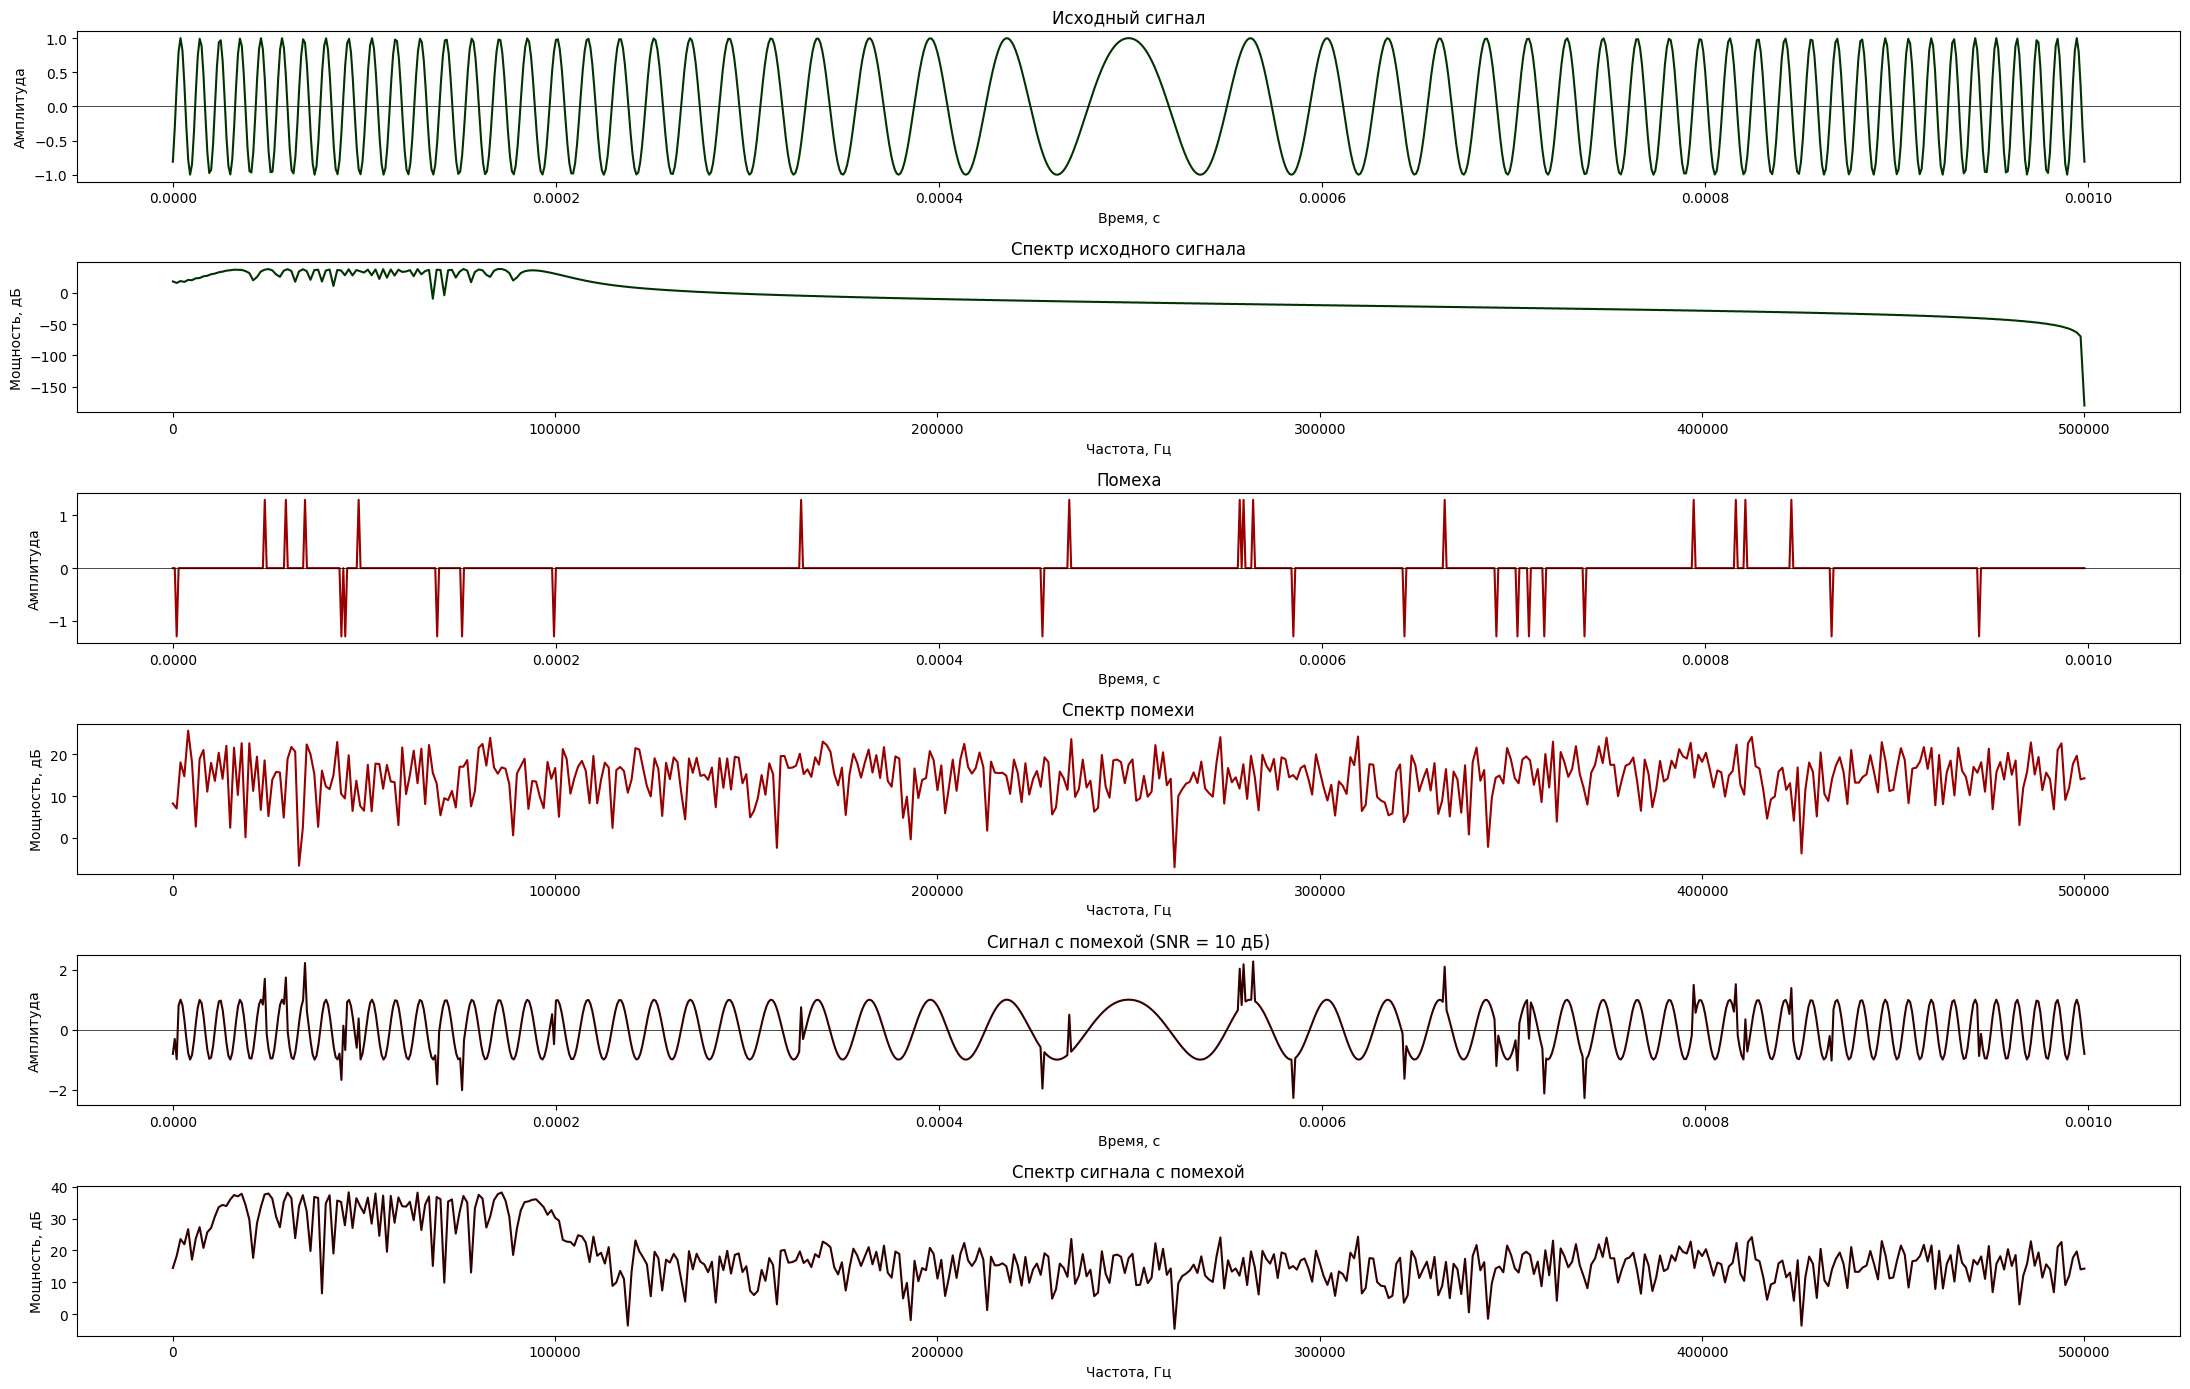

In [15]:
fs = 1e6  # Частота дискретизации, Гц
T = 1e-3  # Длительность сигнала, с
f0 = 2e4  # Центральная частота сигнала, Гц
f_start = 1e4 # Начальная частота для ЛЧМ, Гц
f_stop = 1e5 # Конечная частота для ЛЧМ, Гц
SNR_dB = 10  # Отношение сигнал/шум в дБ
f_start_noise = 1e3 # начальная частота полосы помехи (Гц)
f_stop_noise = 1e5 # конечная частота полосы помехи (Гц)

# Генерация сигнала
# signal, t = generate_signal(fs, T, f0) # Простой прямоугольный радиоимпульс
# signal, t = generate_lfm_pulse(fs, T, f_start, f_stop) # Прямоугольный радиоимпульс с внутриимпульсной ЛЧМ
signal, t = generate_symmetric_lfm(fs, T, f_start, f_stop) # Прямоугольный радиоимпульс с внутриимпульсной симметричной ЛЧМ
# signal, t = generate_bpsk(fs, T, f0) # BPSK-сигнал с случайной фазовой манипуляцией
# signal, t = generate_ofdm(fs, T, f0) # OFDM-сигнал с ортогональными поднесущими
# signal, t = generate_dsss(fs, T, f0) # DSSS-сигнал с псевдослучайным кодом
# signal, t = generate_qam16(fs, T, f0) # QAM16-сигнал с 16-позиционной амплитудно-фазовой манипуляцией
# signal, t = generate_fsk(fs, T, f0) # FSK-сигнал с двоичной частотной манипуляцией

# Генерация шума
# noise = generate_awgn(len(signal))
# noise = generate_narrowband_interference(len(signal), fs, f_start_noise, f_stop_noise)
noise = generate_impulsive(len(signal))

# Зашумление сигнала
noisy_signal = add_noise(signal, noise, SNR_dB)

def calculate_spectrum(signal, fs):
  N = len(signal)
  freqs = np.fft.rfftfreq(N, d=1/fs) # rfftfreq возвращает шкалу частот для rfft
  spectrum = np.abs(np.fft.rfft(signal)) # Считаем амплитудный спектр
  spectrum_db = 20 * np.log10(spectrum + 1e-9) # Переводим в дБ
  return freqs, spectrum_db

# Расчет спектров
freqs_signal, spectrum_signal = calculate_spectrum(signal, fs)
freqs_noise, spectrum_noise = calculate_spectrum(noisy_signal - signal, fs)
freqs_noisy, spectrum_noisy = calculate_spectrum(noisy_signal, fs)

plt.figure(figsize=(22, 14))
plt.subplot(6, 1, 1)
plt.plot(t, signal, color='#003300')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.title('Исходный сигнал')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')

plt.subplot(6, 1, 2)
plt.plot(freqs_signal, spectrum_signal, color='#003300')
plt.title('Спектр исходного сигнала')
plt.xlabel('Частота, Гц')
plt.ylabel('Мощность, дБ')

plt.subplot(6, 1, 3)
plt.plot(t, noisy_signal - signal, color='#990000')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.title('Помеха')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')

plt.subplot(6, 1, 4)
plt.plot(freqs_noise, spectrum_noise, color='#990000')
plt.title('Спектр помехи')
plt.xlabel('Частота, Гц')
plt.ylabel('Мощность, дБ')

plt.subplot(6, 1, 5)
plt.plot(t, noisy_signal, color='#330000')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.title(f'Сигнал с помехой (SNR = {SNR_dB} дБ)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')

plt.subplot(6, 1, 6)
plt.plot(freqs_noisy, spectrum_noisy, color='#330000')
plt.title('Спектр сигнала с помехой')
plt.xlabel('Частота, Гц')
plt.ylabel('Мощность, дБ')

plt.tight_layout()
plt.show()


# Cоздание обучающей и тестовой выборок

In [17]:
import pandas as pd

def generate_dataset(samples_per_pair, snr_range, fs, T):
  N = int(fs * T)
  signal_generators = {
    'Sin': lambda: generate_signal(fs, T, np.random.uniform(1e4, 1e5)),
    'SymLFM': lambda: generate_symmetric_lfm(fs, T, np.random.uniform(1e4, 5e4), np.random.uniform(6e4, 1e5)),
    'BPSK': lambda: generate_bpsk(fs, T, np.random.uniform(2e4, 6e4)),
    'OFDM': lambda: generate_ofdm(fs, T, np.random.uniform(3e4, 7e4)),
    'DSSS': lambda: generate_dsss(fs, T, np.random.uniform(3e4, 7e4)),
    'QAM-16': lambda: generate_qam16(fs, T, np.random.uniform(3e4, 8e4)),
    'FSK': lambda: generate_fsk(fs, T, np.random.uniform(2e4, 6e4))
  }

  noise_generators = {
    'AWGN': lambda n: generate_awgn(n),
    'Narrowband': lambda n: generate_random_bandpass_noise(n, fs),
    'Impulsive': lambda n: generate_impulsive(n)
  }

  X = []
  Y = []

  for s_name, s_func in signal_generators.items():
    for n_name, n_func in noise_generators.items():
      for _ in range(samples_per_pair):
        sig, _ = s_func() # генерируем чистый сигнал
        noise = n_func(len(sig)) # генерируем шум
        snr = np.random.uniform(snr_range[0], snr_range[1]) # выбираем случайный ОСШ из диапазона
        noisy_sig = add_noise(sig, noise, snr) # смешиваем
        X.append(noisy_sig)
        Y.append({
          'signal_type': s_name,
          'noise_type': n_name,
          'snr_db': snr
        })

  return np.array(X), pd.DataFrame(Y)

fs = 1e6
T = 1e-3
samples_per_pair = 1000
snr_range = (0, 30)

X_train, Y_train = generate_dataset(samples_per_pair, snr_range, fs, T)

X_fft = np.array([calculate_spectrum(sig, fs)[1] for sig in X_train]) # преобразуем в спектр, нам нужен только второй возвращаемый аргумент

print(f"Форма X: {X_fft.shape}")
Y_train

Форма X: (21000, 501)


,signal_type,noise_type,snr_db
0,Sin,AWGN,9.698935
1,Sin,AWGN,18.882729
2,Sin,AWGN,19.068170
3,Sin,AWGN,15.273198
4,Sin,AWGN,25.557640
...,...,...,...
20995,FSK,Impulsive,16.174472
20996,FSK,Impulsive,28.339379
20997,FSK,Impulsive,19.923146
20998,FSK,Impulsive,22.567720


# Нормализация

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# scaler ожидает (samples, features), у нас так и есть
X_scaled = scaler.fit_transform(X_train)
X_input = np.expand_dims(X_scaled, axis=-1)

print(f"Новая форма входных данных: {X_input.shape}")

Новая форма входных данных: (21000, 1000, 1)


# Обучение ИНС

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Кодируем названия сигналов и помех в числа
le_signal = LabelEncoder()
y_sig = le_signal.fit_transform(Y_train['signal_type']) # тип модуляции

le_noise = LabelEncoder()
y_noise = le_noise.fit_transform(Y_train['noise_type']) # Тип помехи

y_snr = Y_train['snr_db'].values #непрерывное значение ОСШ для регрессии

indices = np.arange(len(X_input))
# Разделяем на обучающую и проверочную выборки, используем индексы для синхронного разделения всех трех выходов
idx_train, idx_val = train_test_split(np.arange(len(X_input)), test_size=0.2, random_state=42)

X_tr, X_val = X_input[idx_train], X_input[idx_val]
y_sig_tr, y_sig_val = y_sig[idx_train], y_sig[idx_val]
y_noise_tr, y_noise_val = y_noise[idx_train], y_noise[idx_val]
y_snr_tr, y_snr_val = y_snr[idx_train], y_snr[idx_val]

# Входной слой принимает сигнал длиной 1000 отсчетов
inputs = layers.Input(shape=(X_tr.shape[1], 1))

# Функция для создания блоков свертки. Свертка ищет характерные паттерны в сигнале
def conv_block(x, filters, kernel_size):
  # filters - количество фильтров, которые ищут разные признаки
  # kernel_size - размер окна, которым смотрим на сигнал
  x = layers.Conv1D(filters, kernel_size, padding='same')(x)
  x = layers.BatchNormalization()(x) # Стабилизирует обучение
  x = layers.Activation('relu')(x)
  x = layers.MaxPooling1D(2)(x)
  return x

x = conv_block(inputs, 64, 7)
x = conv_block(x, 128, 5)
x = conv_block(x, 256, 3)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Выходы
out_sig = layers.Dense(len(le_signal.classes_), activation='softmax', name='sig_out')(x)
out_noise = layers.Dense(len(le_noise.classes_), activation='softmax', name='noise_out')(x)
out_snr = layers.Dense(1, activation='linear', name='snr_out')(x)

model = models.Model(inputs=inputs, outputs=[out_sig, out_noise, out_snr])

model.compile(
  optimizer='adam',
  loss={
    'sig_out': 'sparse_categorical_crossentropy',
    'noise_out': 'sparse_categorical_crossentropy',
    'snr_out': 'mae'  # средняя абсолютная ошшибка
  },
  loss_weights={
    'sig_out': 1.0,
    'noise_out': 1.0,
    'snr_out': 0.1  # снижаем вес ОСШ, чтобы ошибка не сбивала всю модель
  },
  metrics={'sig_out': 'accuracy', 'noise_out': 'accuracy', 'snr_out': 'mae'}
)

# Eсли val_loss не падает 3 эпохи, снижаем скорость обучения в 2 раза
lr_scheduler = ReduceLROnPlateau(
  monitor='val_loss',
  factor=0.5, # снижаем в 2 раза
  patience=3, # ждем 3 эпохи без улучшений
  verbose=1,
  min_lr=1e-6
)

# Если модель перестала учиться
early_stop = EarlyStopping(
  monitor='val_loss',
  patience=10, # Даем 10 шансов на исправление
  restore_best_weights=True # Возвращаем веса самой лучшей попытки
)

history = model.fit(
  X_tr,
  {'sig_out': y_sig_tr, 'noise_out': y_noise_tr, 'snr_out': y_snr_tr},
  validation_data=(X_val, {'sig_out': y_sig_val, 'noise_out': y_noise_val, 'snr_out': y_snr_val}),
  epochs=40,
  batch_size=128,
  callbacks=[early_stop, lr_scheduler],
  verbose=1
)

Epoch 1/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - loss: 2.5215 - noise_out_accuracy: 0.5979 - noise_out_loss: 0.8640 - sig_out_accuracy: 0.6408 - sig_out_loss: 0.9540 - snr_out_loss: 6.9837 - snr_out_mae: 7.0029 - val_loss: 6.5337 - val_noise_out_accuracy: 0.5529 - val_noise_out_loss: 0.9444 - val_sig_out_accuracy: 0.1662 - val_sig_out_loss: 4.9364 - val_snr_out_loss: 6.5022 - val_snr_out_mae: 6.5047 - learning_rate: 0.0010
Epoch 2/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - loss: 1.4100 - noise_out_accuracy: 0.8036 - noise_out_loss: 0.4942 - sig_out_accuracy: 0.7673 - sig_out_loss: 0.6050 - snr_out_loss: 3.1057 - snr_out_mae: 3.1080 - val_loss: 5.5499 - val_noise_out_accuracy: 0.4912 - val_noise_out_loss: 1.2866 - val_sig_out_accuracy: 0.2917 - val_sig_out_loss: 3.1107 - val_snr_out_loss: 11.5005 - val_snr_out_mae: 11.4997 - learning_rate: 0.0010
Epoch 3/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - loss: 1.1080 - noise_out_accuracy: 0.8579 - noise_out_loss: 0.3689 - sig_out_

## Сохранение модели

In [33]:
# Сохраняем модель в файл
model.save('signal_classifier.keras')
print("Модель сохранена как signal_classifier.keras")

Модель сохранена как signal_classifier_v1.keras


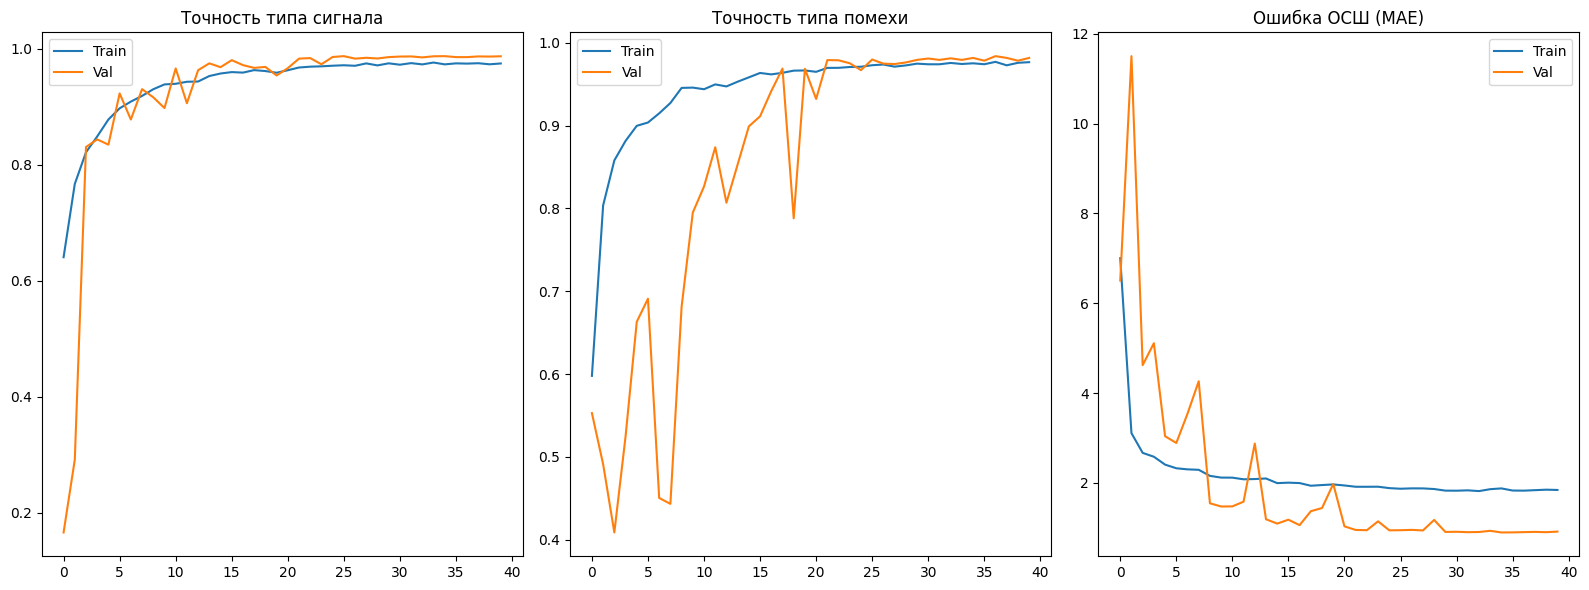

In [21]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.plot(history.history['sig_out_accuracy'], label='Train')
plt.plot(history.history['val_sig_out_accuracy'], label='Val')
plt.title('Точность типа сигнала')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['noise_out_accuracy'], label='Train')
plt.plot(history.history['val_noise_out_accuracy'], label='Val')
plt.title('Точность типа помехи')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['snr_out_mae'], label='Train')
plt.plot(history.history['val_snr_out_mae'], label='Val')
plt.title('Ошибка ОСШ (MAE)')
plt.legend()

plt.tight_layout()
plt.show()

# Оценка ИНС

132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step


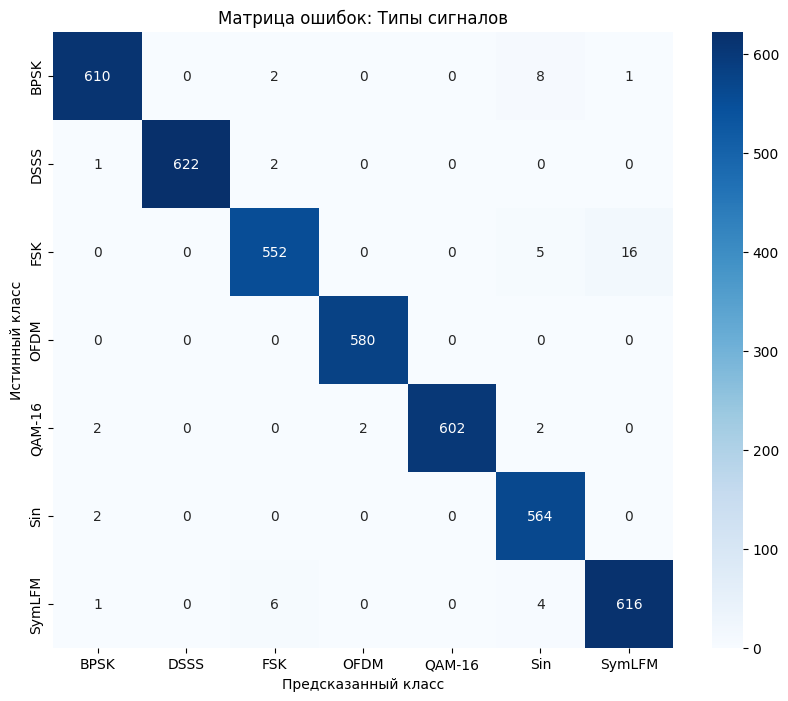

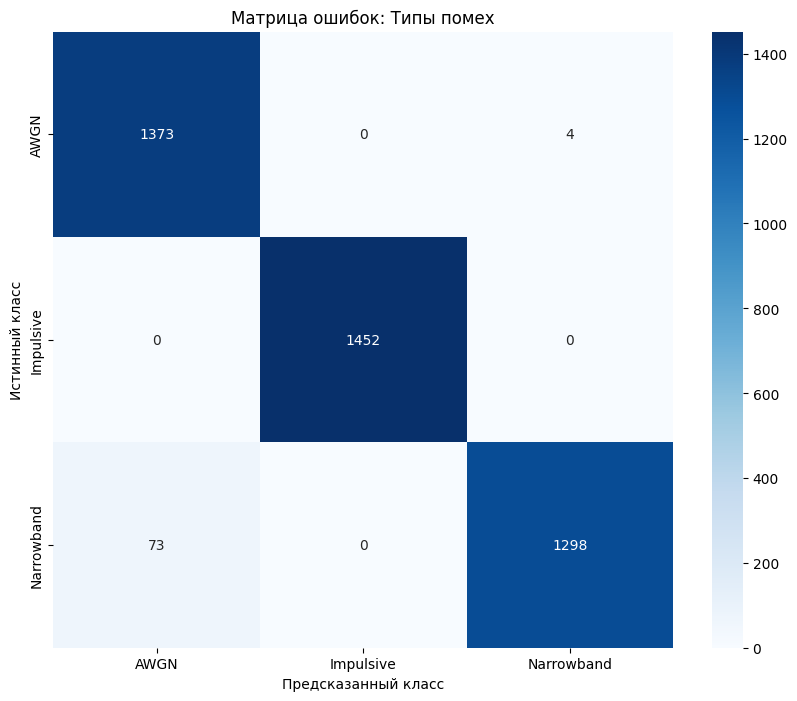

Отчет по классификации сигналов
              precision    recall  f1-score   support

        BPSK       0.99      0.98      0.99       621
        DSSS       1.00      1.00      1.00       625
         FSK       0.98      0.96      0.97       573
        OFDM       1.00      1.00      1.00       580
      QAM-16       1.00      0.99      1.00       608
         Sin       0.97      1.00      0.98       566
      SymLFM       0.97      0.98      0.98       627

    accuracy                           0.99      4200
   macro avg       0.99      0.99      0.99      4200
weighted avg       0.99      0.99      0.99      4200



In [25]:
from sklearn.metrics import classification_report, confusion_matrix

# Получаем предсказания модели на валидационной выборке
predictions = model.predict(X_val)

pred_sig = np.argmax(predictions[0], axis=1)
pred_noise = np.argmax(predictions[1], axis=1)
pred_snr = predictions[2].flatten()

def plot_conf_matrix(y_true, y_pred, classes, title):
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(10, 8))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=classes, yticklabels=classes)
  plt.title(title)
  plt.ylabel('Истинный класс')
  plt.xlabel('Предсказанный класс')
  plt.show()

# Матрицы ошибок
plot_conf_matrix(y_sig_val, pred_sig, le_signal.classes_, 'Матрица ошибок: Типы сигналов')
plot_conf_matrix(y_noise_val, pred_noise, le_noise.classes_, 'Матрица ошибок: Типы помех')

print("Отчет по классификации сигналов")
print(classification_report(y_sig_val, pred_sig, target_names=le_signal.classes_))

In [26]:
# Создаем таблицу для анализа
results_df = pd.DataFrame({
  'true_sig': le_signal.inverse_transform(y_sig_val),
  'true_noise': le_noise.inverse_transform(y_noise_val),
  'true_snr': y_snr_val,
  'pred_snr': pred_snr
})

results_df['snr_error'] = np.abs(results_df['true_snr'] - results_df['pred_snr'])

print("Анализ ошибки ОСШ (MAE) по типам")
print("\nОшибка по типам сигналов:")
print(results_df.groupby('true_sig')['snr_error'].mean())

print("\nОшибка по типам помех:")
print(results_df.groupby('true_noise')['snr_error'].mean())

# Метрики регрессии
from sklearn.metrics import mean_squared_error, r2_score
print(f"\nОбщий R2 Score (ОСШ): {r2_score(y_snr_val, pred_snr):.4f}")
print(f"Общий MSE (ОСШ): {mean_squared_error(y_snr_val, pred_snr):.4f}")

Анализ ошибки ОСШ (MAE) по типам

Ошибка по типам сигналов:
true_sig
BPSK      0.719873
DSSS      0.902262
FSK       0.853498
OFDM      1.198406
QAM-16    1.287728
Sin       0.770648
SymLFM    0.649442
Name: snr_error, dtype: float64

Ошибка по типам помех:
true_noise
AWGN          0.631396
Impulsive     1.034090
Narrowband    1.057971
Name: snr_error, dtype: float64

Общий R2 Score (ОСШ): 0.9730
Общий MSE (ОСШ): 2.0149


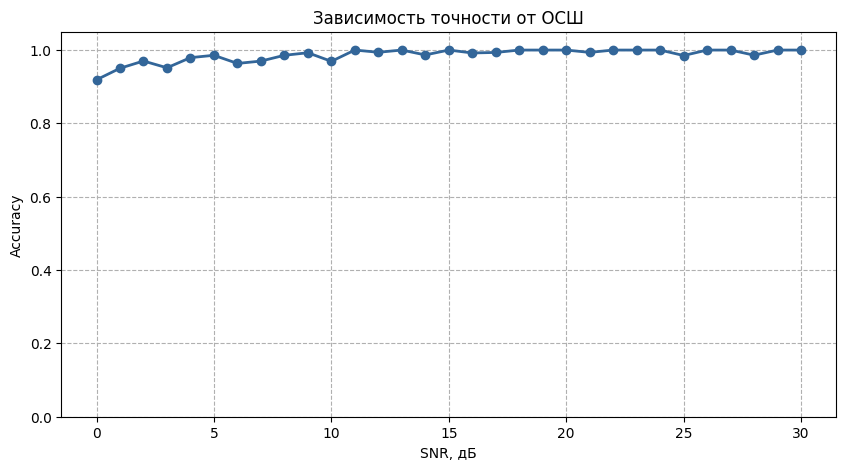

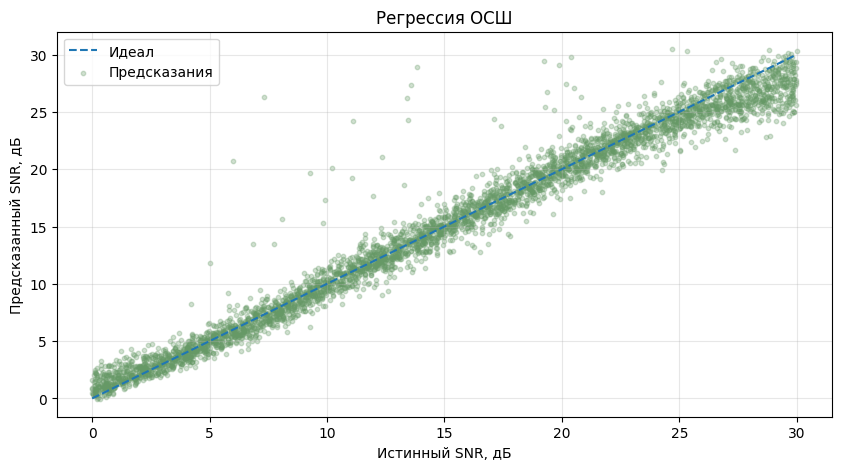

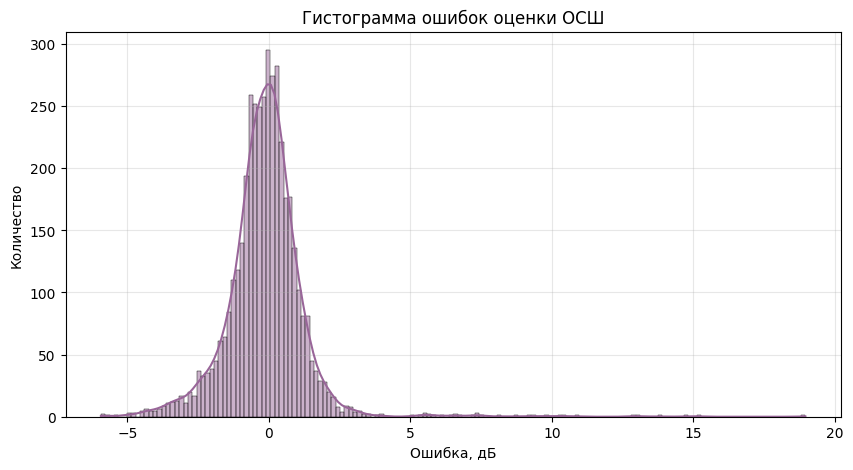

In [32]:
from sklearn.metrics import accuracy_score

# Accuracy vs SNR
snr_bins = np.unique(np.round(y_snr_val))
acc_per_snr = []

for s in snr_bins:
  mask = (np.round(y_snr_val) == s)
  acc = accuracy_score(y_sig_val[mask], pred_sig[mask])
  acc_per_snr.append(acc)

plt.figure(figsize=(10, 5))
plt.plot(snr_bins, acc_per_snr, 'o-', linewidth=2, color='#336699')
plt.grid(True, linestyle='--')
plt.title('Зависимость точности от ОСШ')
plt.xlabel('SNR, дБ')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.show()

# SNR Regression
plt.figure(figsize=(10, 5))
plt.plot([min(y_snr_val), max(y_snr_val)], [min(y_snr_val), max(y_snr_val)], '--', label='Идеал')
plt.scatter(y_snr_val, pred_snr, alpha=0.3, s=10, color='#669966', label='Предсказания')
plt.title('Регрессия ОСШ')
plt.xlabel('Истинный SNR, дБ')
plt.ylabel('Предсказанный SNR, дБ')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Распределение ошибок регрессии
errors = pred_snr - y_snr_val
plt.figure(figsize=(10, 5))
sns.histplot(errors, kde=True, color='#996699')
plt.title('Гистограмма ошибок оценки ОСШ')
plt.xlabel('Ошибка, дБ')
plt.ylabel('Количество')
plt.grid(alpha=0.3)
plt.show()